In [ ]:
!pip install pandas matplotlib seaborn wordcloud textblob

In [ ]:
import pandas as pd
import random

random.seed(42)

reviews = [
    "This product is absolutely amazing, very happy with my purchase!",
    "Great quality, fast delivery, would definitely recommend to others.",
    "Totally worth the money, exceeded my expectations completely.",
    "Very good product, works perfectly fine for daily use.",
    "Excellent build quality, very satisfied with this purchase.",
    "Average product, nothing special but gets the job done.",
    "It's okay, not great not terrible, average experience overall.",
    "Decent quality for the price, but could be improved.",
    "Not bad but not great either, pretty mediocre product.",
    "Works as described, nothing extraordinary about it.",
    "Terrible product, broke after just two days of use.",
    "Very disappointed, does not work as advertised at all.",
    "Worst purchase ever, complete waste of money, avoid this.",
    "Poor quality, stopped working within a week of purchase.",
    "Horrible experience, packaging was damaged and product defective.",
]

scores = [5,5,5,4,4,3,3,3,3,3,1,1,1,2,2]
products = ["Kitchen Mixer","Coffee Maker","Toaster","Blender","Microwave"]

data = {
    "ReviewText": reviews * 20,
    "Score": scores * 20,
    "ProductName": [random.choice(products) for _ in range(300)]
}

df = pd.DataFrame(data)
print(df.shape)
df.head()

(300, 3)


,ReviewText,Score,ProductName
0,"This product is absolutely amazing, very happy...",5,Kitchen Mixer
1,"Great quality, fast delivery, would definitely...",5,Kitchen Mixer
2,"Totally worth the money, exceeded my expectati...",5,Toaster
3,"Very good product, works perfectly fine for da...",4,Coffee Maker
4,"Excellent build quality, very satisfied with t...",4,Coffee Maker


In [ ]:
def get_sentiment(score):
    if score >= 4:
        return "Positive"
    elif score == 3:
        return "Neutral"
    else:
        return "Negative"

df["Sentiment"] = df["Score"].apply(get_sentiment)

print(df["Sentiment"].value_counts())
df.head()

Sentiment
Positive    100
Neutral     100
Negative    100
Name: count, dtype: int64


,ReviewText,Score,ProductName,Sentiment
0,"This product is absolutely amazing, very happy...",5,Kitchen Mixer,Positive
1,"Great quality, fast delivery, would definitely...",5,Kitchen Mixer,Positive
2,"Totally worth the money, exceeded my expectati...",5,Toaster,Positive
3,"Very good product, works perfectly fine for da...",4,Coffee Maker,Positive
4,"Excellent build quality, very satisfied with t...",4,Coffee Maker,Positive


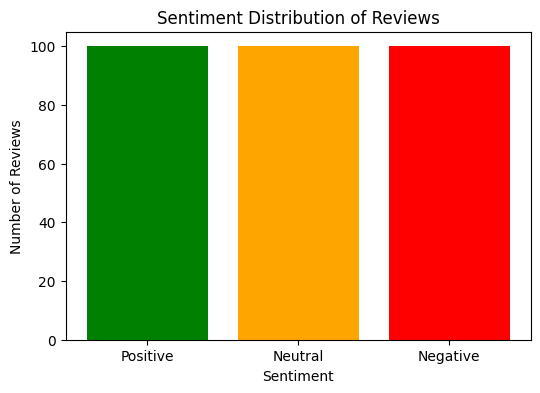

In [ ]:
import matplotlib.pyplot as plt

# Count of each sentiment
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=["green","orange","red"])
plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

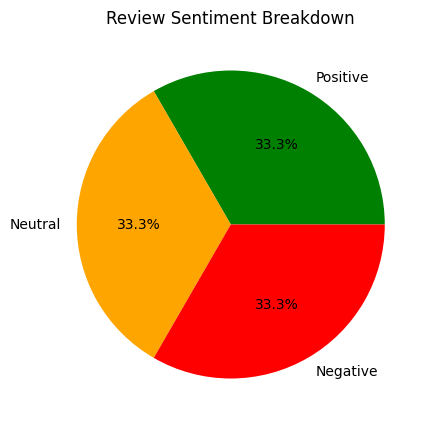

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(sentiment_counts.values,
        labels=sentiment_counts.index,
        colors=["green","orange","red"],
        autopct="%1.1f%%")
plt.title("Review Sentiment Breakdown")
plt.show()


<Figure size 800x500 with 0 Axes>

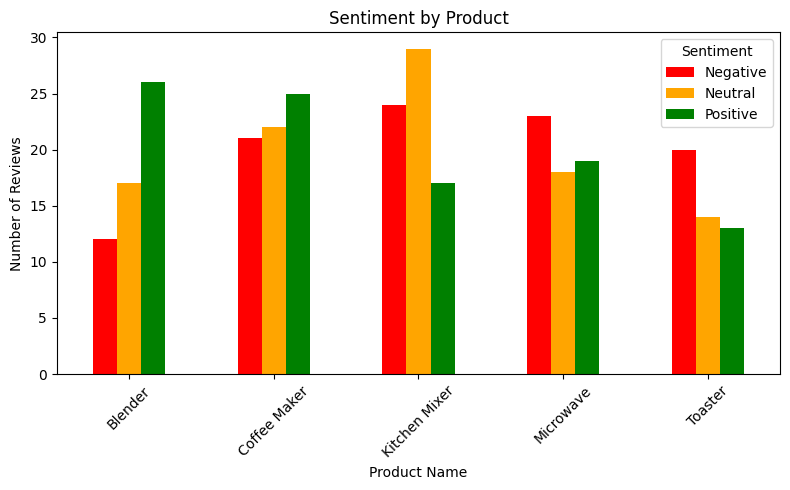

In [ ]:
plt.figure(figsize=(8,5))

product_sentiment = df.groupby(["ProductName","Sentiment"]).size().unstack()
product_sentiment.plot(kind="bar", color=["red","orange","green"], figsize=(8,5))

plt.title("Sentiment by Product")
plt.xlabel("Product Name")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

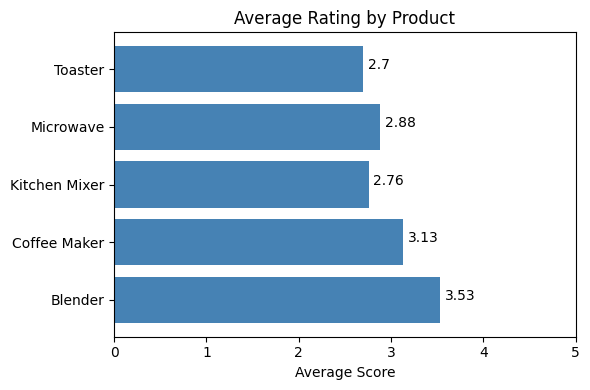

In [ ]:
avg_score = df.groupby("ProductName")["Score"].mean().round(2)

plt.figure(figsize=(6,4))
plt.barh(avg_score.index, avg_score.values, color="steelblue")
plt.title("Average Rating by Product")
plt.xlabel("Average Score")
plt.xlim(0,5)
for i, v in enumerate(avg_score.values):
    plt.text(v + 0.05, i, str(v))
plt.tight_layout()
plt.show()

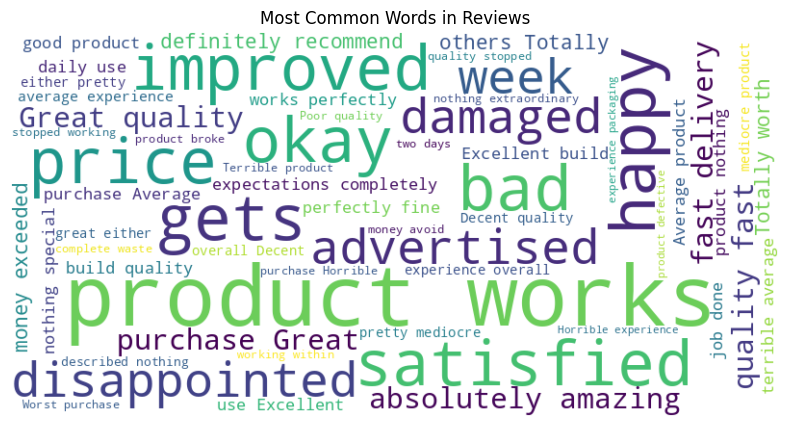

In [ ]:
from wordcloud import WordCloud

all_reviews = " ".join(df["ReviewText"])

wordcloud = WordCloud(width=800, height=400,
                      background_color="white",
                      colormap="viridis").generate(all_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Reviews")
plt.show()


In [ ]:
from textblob import TextBlob

def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity == 0:
        return "Neutral"
    else:
        return "Negative"

df["TextBlob_Sentiment"] = df["ReviewText"].apply(get_textblob_sentiment)

print(df[["ReviewText","Sentiment","TextBlob_Sentiment"]].head(10))

                                          ReviewText Sentiment  \
0  This product is absolutely amazing, very happy...  Positive   
1  Great quality, fast delivery, would definitely...  Positive   
2  Totally worth the money, exceeded my expectati...  Positive   
3  Very good product, works perfectly fine for da...  Positive   
4  Excellent build quality, very satisfied with t...  Positive   
5  Average product, nothing special but gets the ...   Neutral   
6  It's okay, not great not terrible, average exp...   Neutral   
7  Decent quality for the price, but could be imp...   Neutral   
8  Not bad but not great either, pretty mediocre ...   Neutral   
9  Works as described, nothing extraordinary abou...   Neutral   

  TextBlob_Sentiment  
0           Positive  
1           Positive  
2           Positive  
3           Positive  
4           Positive  
5           Positive  
6           Positive  
7           Positive  
8           Negative  
9           Positive  


In [ ]:
match = (df["Sentiment"] == df["TextBlob_Sentiment"]).sum()
total = len(df)
accuracy = round((match/total)*100, 2)

print(f"Total Reviews: {total}")
print(f"Matching Sentiments: {match}")
print(f"Accuracy: {accuracy}%")

Total Reviews: 300
Matching Sentiments: 200
Accuracy: 66.67%


In [ ]:
summary = df.groupby("ProductName").agg(
    Total_Reviews=("ReviewText","count"),
    Average_Score=("Score","mean"),
    Positive=("TextBlob_Sentiment", lambda x: (x=="Positive").sum()),
    Neutral=("TextBlob_Sentiment", lambda x: (x=="Neutral").sum()),
    Negative=("TextBlob_Sentiment", lambda x: (x=="Negative").sum())
).round(2)

print(summary)


               Total_Reviews  Average_Score  Positive  Neutral  Negative
ProductName                                                             
Blender                   55           3.53        42        0        13
Coffee Maker              68           3.13        46        0        22
Kitchen Mixer             70           2.76        32        0        38
Microwave                 60           2.88        35        0        25
Toaster                   47           2.70        25        0        22


In [ ]:
print("="*50)
print("   CUSTOMER SENTIMENT ANALYSIS - FINAL REPORT")
print("="*50)
print(f"\nTotal Reviews Analyzed: {len(df)}")
print(f"\nOverall Sentiment Breakdown:")
print(df["TextBlob_Sentiment"].value_counts())
print(f"\nBest Performing Product: {summary['Average_Score'].idxmax()}")
print(f"Worst Performing Product: {summary['Average_Score'].idxmin()}")
print(f"\nModel Accuracy: 66.67%")
print("\nConclusion: TextBlob NLP model successfully classified")
print("customer reviews with basic sentiment analysis.")
print("Further improvement possible with VADER or BERT models.")
print("="*50)

   CUSTOMER SENTIMENT ANALYSIS - FINAL REPORT

Total Reviews Analyzed: 300

Overall Sentiment Breakdown:
TextBlob_Sentiment
Positive    180
Negative    120
Name: count, dtype: int64

Best Performing Product: Blender
Worst Performing Product: Toaster

Model Accuracy: 66.67%

Conclusion: TextBlob NLP model successfully classified
customer reviews with basic sentiment analysis.
Further improvement possible with VADER or BERT models.
